# Modelització de Reserves Actuarials en No Vida - @paucoca

En el sector assegurador (especialment en els rams de No Vida), el model de negoci es basa en el cobrament anticipat d'una prima a canvi de la promesa de fer front a possibles sinistres futurs. Com que el cost real d'aquests sinistres no es coneix en el moment de tancar l'exercici, és imprescindible calcular i dotar les **Reserves Tècniques** (o provisions).

## 1. Conceptes Fonamentals

La provisió més important és la **PSAP (Provisió per a Sinistres a Pagar)**, que representa l'estimació del valor necessari per cobrir tots els sinistres que ja han ocorregut, però que encara no s'han acabat de pagar. Es divideix en dos grans components:

* **RBNS (Reported But Not Settled):** Són aquells sinistres que ja han estat declarats per l'assegurat, però que encara es troben en fase de tramitació o liquidació.
* **IBNR (Incurred But Not Reported):** Són els sinistres que ja han succeït (per exemple, un accident el dia abans de tancar l'any), però que l'asseguradora encara no coneix perquè no han estat reportats. S'han d'estimar mitjançant models estadístics.
* A banda, trobem la **UPR (Unearned Premium Reserve)**, que fa referència a la part de les primes cobrades que corresponen a períodes de risc futurs (primes no consumides). És a dir, la part de la prima que l'asseguradora ja ha cobrat, però que encara no ha "guanyat" perquè el període de cobertura encara no ha passat.

## 3. Mètodologies de Càlcul (Reserving)

L'eina de treball principal per modelitzar l'evolució dels pagaments és el **triangle de sinistres**, que ordena les dades per any d'ocurrència (files) i any de desenvolupament (columnes). En aquest projecte s'implementen els següents mètodes:

1.  **Mètode Chain Ladder:** És un mètode determinista que calcula "factors de desenvolupament" basant-se en com han crescut els pagaments històricament, per projectar-los cap al futur.
    * *Supòsit clau:* Assumeix que els patrons de desenvolupament passats es mantindran estables en el futur. És molt sensible a dades atípiques (*outliers*) i canvis recents.
2.  **Mètode Bornhuetter-Ferguson (BF):** És un mètode híbrid que combina l'experiència històrica del triangle amb una estimació a priori externa (l'*expected loss ratio*).
    * *Avantatge:* És molt menys sensible a les anomalies a curt termini. Resulta ideal per estimar les reserves dels anys d'ocurrència més recents, on les dades observades encara són escasses o poc madures.

##  Detecció d'Outliers i Qualitat de Dades

Abans d'aplicar qualsevol mètode de projecció actuarial (com el Chain Ladder), és imprescindible assegurar la qualitat de les dades històriques. La presència de valors atípics (*outliers*) en un triangle de pagaments pot distorsionar completament els factors de desenvolupament i, en conseqüència, el càlcul final de les reserves.

A continuació, definim el triangle incremental de sinistres i utilitzem un mapa de calor (*heatmap*) per a la detecció visual d'anomalies.

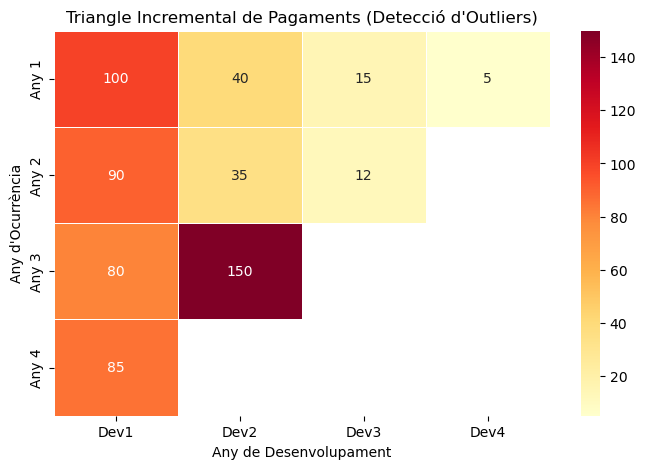

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Creem un triangle incremental de pagaments d'exemple (amb un outlier intencionat)
data = {
    'Dev1': [100, 90, 80, 85],
    'Dev2': [40, 35, 150, None], # El 150 és un outlier clar
    'Dev3': [15, 12, None, None],
    'Dev4': [5, None, None, None]
}
triangle_inc = pd.DataFrame(data_inc, index=['Any 1', 'Any 2', 'Any 3', 'Any 4'])

# Visualització del Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(triangle_inc, annot=True, fmt=".0f", cmap="YlOrRd", cbar=True, linewidths=.5)
plt.title("Triangle Incremental de Pagaments (Detecció d'Outliers)")
plt.xlabel("Any de Desenvolupament")
plt.ylabel("Any d'Ocurrència")
plt.show()

# S'observa un pic inusual (150) a l'Any 3 / Dev2. 
# En un entorn real, s'hauria de suavitzar abans de projectar reserves.

## Estimació de Reserves de Sinistres (Mètodes Deterministes)

Un cop validada la qualitat de la mostra, procedim a projectar el cost final dels sinistres (*Ultimate Cost*). L'objectiu és determinar la **PSAP (Provisió per a Sinistres a Pagar)**, que inclou tant els sinistres declarats (RBNS) com els no coneguts (IBNR).

El resultat final d'aquesta secció serà el nostre **Best Estimate (BE)**, la peça central per a la valoració sota els marcs de Solvència II i IFRS 17.

In [5]:
import numpy as np
import pandas as pd

# TRIANGLE DE SINISTRES ACUMULATS
# Files: any del sinistre
# Columnes: quant de temps ha passat (desenvolupament)
# Veure els diners acumulats pagats de sinistres
# Hi ha NaNs perquè els anys recents no tenen informació encara

data = {
    1: [100, 120, 130, 150],
    2: [150, 180, 200, np.nan],
    3: [180, 210, np.nan, np.nan],
    4: [200, np.nan, np.nan, np.nan]
}

triangle = pd.DataFrame(data, index=[2019, 2020, 2021, 2022])

print("Triangle de sinistres acumulats:")
print(triangle)

# 2. FACTORS DE DESENVOLUPAMENT
# Factor = Suma(columna següent) / Suma(columna actual)
# Per exemple si volem passar de Dev1 a Dev2: 
# Factor=suma Dev2 /suma Dev1
# Factor(150+180+200)/(100+120+130)=1.51
# Interpretació: històricament els sinistres creixen un 51% de l'any 1 al'any 2.

factors = []

for col in range(1, triangle.shape[1]):
    valid_rows = triangle.iloc[:, col-1].notna() & triangle.iloc[:, col].notna()
    
    factor = (triangle.loc[valid_rows, col+1].sum() /
              triangle.loc[valid_rows, col].sum())
    
    factors.append(factor)

print("\nFactors de desenvolupament:")
for i, f in enumerate(factors):
    print(f"Any {i+1} -> {i+2}: {f:.2f}")


# ESTIMAR VALORS FUTURS (EMPLENAR TRIANGLE)
# Valor futur=valor actual x factor
# Tenim Dev1=150. El factor de 1 a 2 és 1.5
# Dev2 = 150x1.5=225

triangle_est = triangle.copy()

for i in range(len(triangle_est)):
    for j in range(triangle_est.shape[1]):
        if pd.isna(triangle_est.iloc[i, j]):
            triangle_est.iloc[i, j] = triangle_est.iloc[i, j-1] * factors[j-1]

print("\nTriangle completat:")
print(triangle_est)


# ULTIMATE (ÚLTIMA COLUMNA)
# l'ultimate és el cost total que tindrà aquell any de sinistres quan estigui completament desenvolupat.

ultimate = triangle_est.iloc[:, -1]


# 5. RESERVA= ULTIMATE - OBSERVAT(pagat fins avui)
# Exemple: per a 2022, Reserva=298.268398 -150.0=148.268398
observed = triangle.max(axis=1)
reserves = ultimate - observed


# Ara bé, si bé Chain Ladder diu que el futur serà com el passat, si tenim poques dades això no és fiable.
# Bornhuetter-Ferguson té en compte les dades reals (observat) i una estimació prèvia (a priori).
# Per exemple, imaginem que per a un any hem pagat 100 fins ara. S'esperava a priori pagar 200. És a dir, s'ha desenvolupat un 60% i falta el 40 restant.
# Ultimate= 100+ (200*0,4)=100+80=180
# Aquest mètode és més adient per a anys recents.
# El cost total de sinistres que esperaves abans de veure les dades reals es pot calcular amb l'expected loss. 
# Expected loss=prima x loss ratio

# BORNHUETTER-FERGUSON

# Calcular factors acumulats (CDF)
factors_array = np.array(factors)
cdf = np.cumprod(factors_array[::-1])[::-1]

# Afegim 1 al final (últim desenvolupament = complet)
cdf = np.append(cdf, 1)

# Percentatge desenvolupat per cada fila (Optimitzat sense bucle)
idx = triangle.count(axis=1) - 1 
percent_developed = pd.Series(1 / cdf[idx.values], index=triangle.index)

# Expected loss
expected_loss = pd.Series([220, 240, 260, 280], index=triangle.index)

# BF Ultimate
bf_ultimate = observed + expected_loss * (1 - percent_developed)

# Reserva BF
bf_reserve = bf_ultimate - observed

# Consolidem tots els resultats per tenir-ho clar
resultats_finals = pd.DataFrame({
    "Observat": observed,
    "Expected Loss": expected_loss,
    "CL Ultimate": ultimate,
    "CL Reserva": reserves,
    "% Desenvolupat BF": percent_developed,
    "BF Ultimate": bf_ultimate,
    "BF Reserva": bf_reserve
}).round(2)

print("\nResum de Reserves (Chain Ladder vs Bornhuetter-Ferguson):")
print(resultats_finals)

Triangle de sinistres acumulats:
        1      2      3      4
2019  100  150.0  180.0  200.0
2020  120  180.0  210.0    NaN
2021  130  200.0    NaN    NaN
2022  150    NaN    NaN    NaN

Factors de desenvolupament:
Any 1 -> 2: 1.51
Any 2 -> 3: 1.18
Any 3 -> 4: 1.11

Triangle completat:
        1           2           3           4
2019  100  150.000000  180.000000  200.000000
2020  120  180.000000  210.000000  233.333333
2021  130  200.000000  236.363636  262.626263
2022  150  227.142857  268.441558  298.268398

Resum de Reserves (Chain Ladder vs Bornhuetter-Ferguson):
      Observat  Expected Loss  CL Ultimate  CL Reserva  % Desenvolupat BF  \
2019     200.0            220       200.00        0.00               1.00   
2020     210.0            240       233.33       23.33               0.90   
2021     200.0            260       262.63       62.63               0.76   
2022     150.0            280       298.27      148.27               0.50   

      BF Ultimate  BF Reserva  
2019

## Provisió de Primes No Consumides (UPR - Unearned Premium Reserve)

La **UPR** és una provisió tècnica que reflecteix la part de les primes emeses que correspon a períodes de risc futurs. Segons el principi comptable de meritació, una entitat asseguradora no pot reconèixer l'ingrés total d'una prima en el moment exacte del seu cobrament, ja que el servei de cobertura i l'exposició al risc s'estenen al llarg de tota la vigència del contracte. 

* **Metodologia de càlcul:** El mètode estàndard per al seu càlcul és el sistema *pro-rata temporis* (conegut també com a mètode de la fracció 1/365). Aquest mètode distribueix la prima de manera lineal i proporcional en funció dels dies de vigència que li queden a la pòlissa fins al seu venciment.
* **Objectiu financer:** Aquesta reserva assegura que l'entitat manté al seu balanç el passiu necessari per fer front als sinistres que puguin ocórrer durant la fracció de l'any encara no consumida, o bé per retornar la prima extornada en cas que la pòlissa es cancel·li de manera anticipada.

A continuació, s'implementa el càlcul vectoritzat de la UPR per a una cartera de contractes a data de tancament d'exercici.

In [11]:
from datetime import datetime

# Dades de la nostra cartera a data de tancament (31 de desembre de 2023)
data_tancament = pd.to_datetime('2023-12-31')

polisses = pd.DataFrame({
    'ID_Polissa': ['P001', 'P002', 'P003'],
    'Data_Inici': pd.to_datetime(['2023-01-01', '2023-07-01', '2023-10-01']),
    'Data_Fi': pd.to_datetime(['2023-12-31', '2024-06-30', '2024-09-30']),
    'Prima_Cobrada': [120000, 100000, 80000] # Primes ajustades per ser coherents
})

# Càlcul de dies totals i dies pendents
polisses['Dies_Totals'] = (polisses['Data_Fi'] - polisses['Data_Inici']).dt.days
polisses['Dies_Pendents'] = (polisses['Data_Fi'] - data_tancament).dt.days
polisses['Dies_Pendents'] = polisses['Dies_Pendents'].clip(lower=0)

# Càlcul de la UPR
polisses['UPR'] = (polisses['Prima_Cobrada'] / polisses['Dies_Totals']) * polisses['Dies_Pendents']

# GUARDEM LA PRIMA TOTAL PER UTILITZAR-LA A IFRS 17 MÉS ENDAVANT
prima_total_cartera = polisses['Prima_Cobrada'].sum()

print("Cartera amb el càlcul de la UPR individualitzada:")
print(polisses[['ID_Polissa', 'Prima_Cobrada', 'Dies_Pendents', 'UPR']].round(2))
print(f"\nProvisió UPR Total de la cartera: {polisses['UPR'].sum():.2f} €")

Cartera amb el càlcul de la UPR individualitzada:
  ID_Polissa  Prima_Cobrada  Dies_Pendents       UPR
0       P001         120000              0      0.00
1       P002         100000            182  49863.01
2       P003          80000            274  60054.79

Provisió UPR Total de la cartera: 109917.81 €



## Marc Regulatori: Solvència II (Best Estimate i Risk Margin)

Solvència II és la directiva europea (basada en el risc) que estableix els requeriments de capital per a les companyies d'assegurances. El seu objectiu fonamental és protegir els prenedors de les pòlisses garantint que les entitats tinguin prou solvència per resistir escenaris financers i tècnics extrems (esdeveniments amb una probabilitat d'ocurrència d'1 de cada 200 anys).

El càlcul de les Provisions Tècniques sota aquest marc regulatori  es divideix de forma estricta en dos components:

1.  **Best Estimate (Millor Estimació o BEL):** Representa la mitjana ponderada per probabilitat dels fluxos de caixa futurs necessaris per liquidar les obligacions (pagaments de sinistres, despeses de gestió, etc.). Aquests fluxos es descompten al seu valor actual utilitzant una corba de tipus d'interès lliure de risc proporcionada pel regulador (EIOPA).
2.  **Risk Margin (Marge de Risc):** Reflecteix la incertesa inherent als fluxos de caixa. Es defineix teòricament com l'import addicional que exigiria una altra asseguradora (un tercer independent) per estar disposada a assumir i gestionar aquestes obligacions. Es calcula determinant el cost de capital (fixat normativament en un 6%) aplicat sobre el Capital de Solvència Obligatori (SCR - *Solvency Capital Requirement*) projectat durant tota la vida residual del passiu.

El següent bloc de codi modelitza l'agregació d'aquests components per obtenir el passiu regulatori total.

In [13]:
# Suposem que hem calculat els fluxos futurs (reserves) a partir del triangle netejat
best_estimate = 210000  # Aquest serà el nostre passiu esperat base

# Simplificació: Cost de capital (6%) aplicat sobre el Capital de Solvència Obligatori (SCR)
coste_capital = 0.06
scr_estimat = best_estimate * 0.25  # Assumim que l'exigència de capital és el 25% del BE

risk_margin = scr_estimat * coste_capital

# Provisions Tècniques totals sota Solvència II
prov_tecniques_s2 = best_estimate + risk_margin

print("--- Càlcul Sota Solvència II ---")
print(f"Best Estimate (BEL): {best_estimate:,.2f} €")
print(f"Risk Margin (RM):    {risk_margin:,.2f} €")
print(f"Provisions Tècniques:{prov_tecniques_s2:,.2f} €")


#Què passa si pugem els tipus d'interès a Solvència II: el Best Estimate (que és un valor actual de fluxos futurs) baixaria, perquè estem descomptant els diners a una taxa més alta. Això alliberaria capital.

--- Càlcul Sota Solvència II ---
Best Estimate (BEL): 210,000.00 €
Risk Margin (RM):    3,150.00 €
Provisions Tècniques:213,150.00 €


## Marc Comptable: IFRS 17 i el Marge de Servei Contractual (CSM)

La normativa IFRS 17 substitueix l'antic estàndard IFRS 4, introduint un model de valoració uniforme que busca la màxima transparència financera i la comparabilitat entre entitats. Sota IFRS 17, el passiu per cobertura restant es construeix mitjançant una sèrie de "blocs" (Building Block Approach). 

El concepte central i més innovador d'aquesta norma és el **CSM (*Contractual Service Margin*)**, que representa de manera explícita el benefici no guanyat del contracte. El CSM representa el benefici no guanyat del contracte, el qual s'allibera a la compte de resultats de manera gradual a mesura que es presta el servei d'assegurança. També es pot considerar que el CSM és la diferència positiva entre el que cobres (primes) i el que esperes pagar (sinistres + despeses + ajust per risc) en el moment de signar el contracte. Són diners que esperes que es quedin a la companyia, però que encara no pots repartir com a dividend.

* **Reconeixement Inicial:** En el moment d'emetre la pòlissa, es calcula el valor actual dels fluxos d'entrada (primes) menys els fluxos de sortida esperats (sinistres i despeses), sumant-hi un Ajust per Risc No Financer (*Risk Adjustment*).
    * Si el resultat net demostra un **benefici**, aquest no es reconeix immediatament a la compte de resultats. S'emmagatzema al balanç com a CSM (un passiu).
    * Si el resultat net revela una **pèrdua** (contracte onerós), la norma prohibeix difuminar-la: el CSM és zero i la pèrdua s'ha de reconèixer de manera immediata i íntegra en l'exercici actual.
* **Amortització posterior:** El CSM acumulat s'allibera (*release*) de manera sistemàtica i proporcional a la compte de pèrdues i guanys al llarg del període de cobertura, reflectint fidelment la prestació del servei d'assegurança a mesura que transcorre el temps.

La implementació següent simula la lògica de reconeixement inicial del CSM i la seva consegüent pauta d'amortització teòrica.

In [14]:
# Recuperem les dades de les cel·les anteriors per mantenir la coherència del projecte
prima_emesa = prima_total_cartera  # Primes obtingudes al càlcul de la UPR (300.000 €)
fluxos_esperats = best_estimate    # Passiu esperat obtingut a Solvència II (210.000 €)

ajust_per_risc = fluxos_esperats * 0.04  # Risk Adjustment (exigència d'IFRS 17)
durada_anys = 3                          # Durada mitjana de la cartera

# Càlcul del CSM (Marge de Servei Contractual) Inicial
# CSM = Primes - (Fluxos Esperats + Ajust per Risc)
csm_inicial = prima_emesa - (fluxos_esperats + ajust_per_risc)

print("--- Valoració Inicial IFRS 17 ---")
print(f"Prima Emesa Total: {prima_emesa:,.2f} €")
print(f"Sortides Esperades: {fluxos_esperats:,.2f} €")
print(f"Ajust per Risc: {ajust_per_risc:,.2f} €")
print("-" * 35)

if csm_inicial > 0:
    print(f"Grup de contractes RENTABLE.")
    print(f"CSM Inicial constituït: {csm_inicial:,.2f} €")
    
    # Amortització lineal (simplificada) durant la vida del contracte
    amortitzacio_anual = csm_inicial / durada_anys
    print(f"Impacte en PyG: S'alliberaran {amortitzacio_anual:,.2f} € de benefici cada any durant {durada_anys} anys.")
else:
    print(f"Grup de contractes ONERÓS.")
    print(f"CSM Inicial: 0 €")
    print(f"Impacte en PyG: Es reconeix una pèrdua immediata de {abs(csm_inicial):,.2f} €.")

--- Valoració Inicial IFRS 17 ---
Prima Emesa Total: 300,000.00 €
Sortides Esperades: 210,000.00 €
Ajust per Risc: 8,400.00 €
-----------------------------------
Grup de contractes RENTABLE.
CSM Inicial constituït: 81,600.00 €
Impacte en PyG: S'alliberaran 27,200.00 € de benefici cada any durant 3 anys.
